# AE 03: Tucson Housing + data visualization
### Author: Ripa Shah
### Date: 09/11/2025

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from statsmodels.nonparametric.smoothers_lowess import lowess

## Exercise 1

Suppose you're helping some family friends who are looking to buy a house in Tucson.
As they browse Zillow listings, they realize some houses have garages and others don't, and they wonder: **Does having a garage make a difference?**

Luckily, you can help them answer this question with data visualization!

-   Make histograms of the prices of houses in Tucson based on whether they have a garage.

    -   In order to do this, you will first need to create a new variable called `garage` (with levels `"Garage"` and `"No garage"`).

    -   Below is the code for creating this new variable.
        Here, we transform the `tucson_housing` data frame to add a new variable called `garage` which takes the value `"Garage"` if the house type is "Single Family" or "Townhouse" and takes the value `"No garage"` otherwise.

In [1]:
%cd C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah

C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah


In [10]:
tucson_housing = pd.read_csv("data/tucson_housing.csv")

tucson_housing.head()

print(tucson_housing)

garage_types = ["Single Family", "Townhouse"]

print(garage_types)

tucson_housing['garage'] = tucson_housing['type'].apply(lambda x: 'Garage' if x in garage_types else 'No garage')

print(tucson_housing['garage'])
print(tucson_housing['type'])

                                       address  year_built   price  bed  bath  \
0               710 E 5th St, Tucson, AZ 85719        1936  330000    2     1   
1    3543 N Flowing Wells Rd, Tucson, AZ 85705        1943  260000    2     1   
2             2938 E 21st St, Tucson, AZ 85716        1948  310000    3     1   
3        5510-12 E Lester St, Tucson, AZ 85712        1950  270000    4     2   
4           5510 E Lester St, Tucson, AZ 85712        1950  270000    4     2   
..                                         ...         ...     ...  ...   ...   
107      5802 S Camino Verde, Tucson, AZ 85757        2016  235000    3     2   
108    2780 W Greenstreak Dr, Tucson, AZ 85741        2016  379900    3     2   
109         1132 W Hadley St, Tucson, AZ 85705        2022  285000    3     2   
110      2631 W Partridge St, Tucson, AZ 85746        2022  450000    4     2   
111    5942 S Del Moral Blvd, Tucson, AZ 85706        2023  279000    3     2   

     area           type   

-   Then, facet by `garage` and use different colors for the two facets.
-   Choose an appropriate binwidth and decide whether a legend is needed, and turn it off if not.
-   Include informative title and axis labels.
-   Finally, include a brief (2-3 sentence) narrative comparing the distributions of prices of Tucson houses that do and don't have garages. Your narrative should touch on whether having a garage "makes a difference" in terms of the price of the house.

In [13]:
tucson_housing.describe()
tucson_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   address     112 non-null    object
 1   year_built  112 non-null    int64 
 2   price       112 non-null    int64 
 3   bed         112 non-null    int64 
 4   bath        112 non-null    int64 
 5   area        112 non-null    int64 
 6   type        112 non-null    object
 7   url         112 non-null    object
 8   garage      112 non-null    object
dtypes: int64(5), object(4)
memory usage: 8.0+ KB


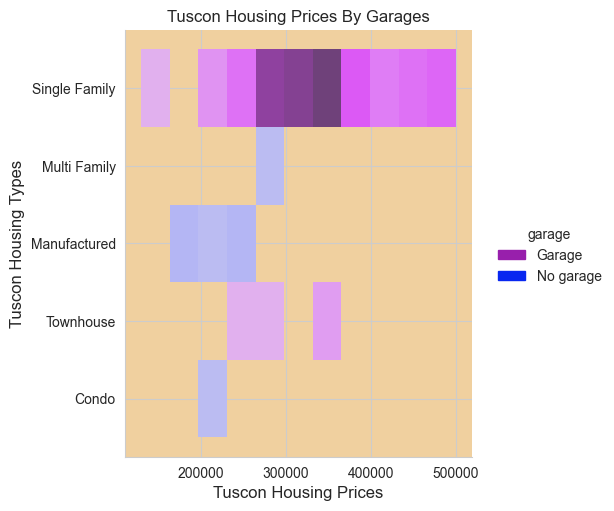

In [68]:
# add code here

#sns.set_style(rc = {'axes.facecolor:"#FE9900"})
sns.set_style(rc = {'axes.facecolor': "#F0D09F"})
plt.Figure(figsize=(10,8))
custom_palette = ["#981FAC", "#0827F0"] # Example hex codes
sns.displot(data=tucson_housing,x='price',y='type',hue='garage', palette=custom_palette)
plt.title("Tuscon Housing Prices By Garages")
#sns.displot(data=tucson_housing,x='year_built',y='type',hue='garage',palette=custom_palette)
plt.xlabel(xlabel='Tuscon Housing Prices',loc='center',fontsize=12)
plt.ylabel(ylabel='Tuscon Housing Types', fontsize=12, loc='center')


plt.show()

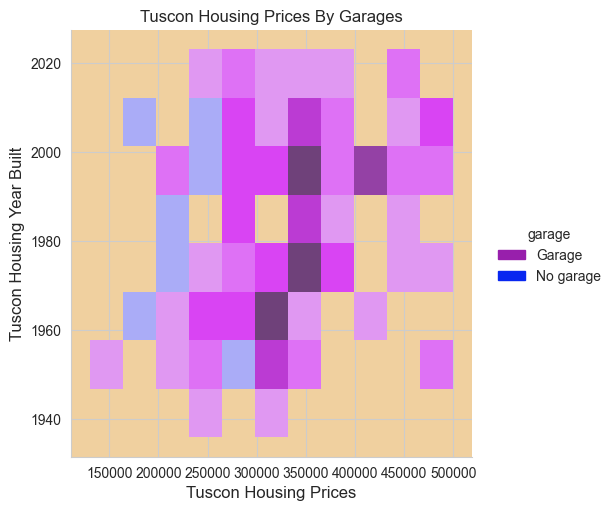

In [86]:
#sns.set_style(rc = {'axes.facecolor:"#FE9900"})
sns.set_style(rc = {'axes.facecolor': "#F0D09F"})
plt.Figure(figsize=(10,8))
custom_palette = ["#981FAC", "#0827F0"] # Example hex codes
sns.displot(data=tucson_housing,x='price',y='year_built',hue='garage', palette=custom_palette)
plt.title("Tuscon Housing Prices By Garages")
#sns.displot(data=tucson_housing,x='year_built',y='type',hue='garage',palette=custom_palette)
plt.xlabel(xlabel='Tuscon Housing Prices',loc='center',fontsize=12)
plt.ylabel(ylabel='Tuscon Housing Year Built', fontsize=12, loc='center')



plt.show()

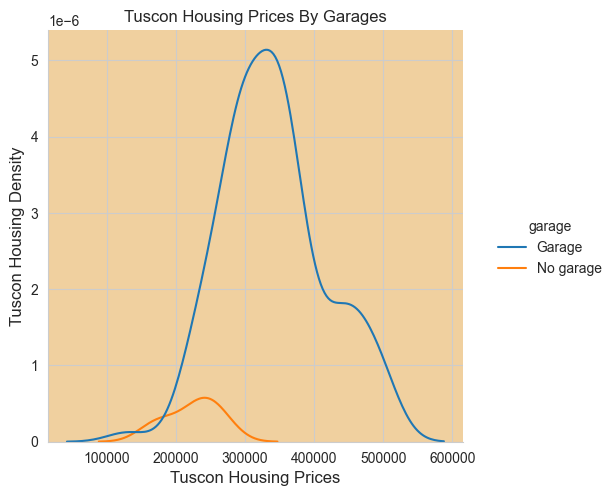

In [ ]:
sns.displot(data=tucson_housing,x='price',hue='garage',kind='kde')
plt.xlabel(xlabel='Tuscon Housing Prices',loc='center',fontsize=12)
plt.ylabel(ylabel='Tuscon Housing Density', fontsize=12, loc='center')
plt.title("Tuscon Housing Prices By Garages")
plt.show()


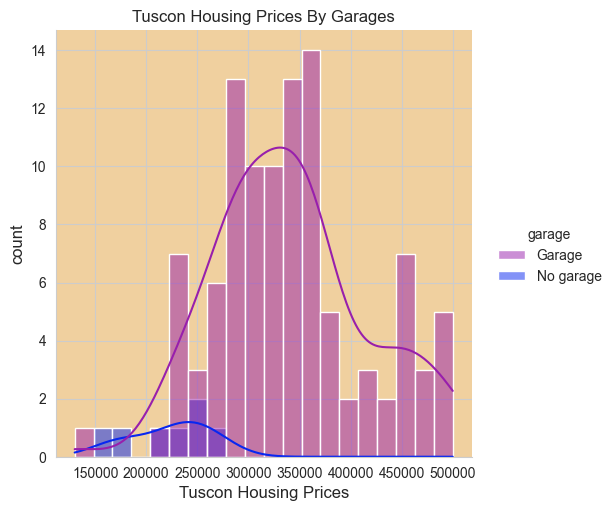

In [89]:
sns.displot(data=tucson_housing, x='price', hue='garage', kind='hist', kde=True, palette=custom_palette, bins=20)
plt.xlabel(xlabel='Tuscon Housing Prices',loc='center',fontsize=12)
plt.ylabel(ylabel='count', fontsize=12, loc='center')
plt.title("Tuscon Housing Prices By Garages")
plt.show()
plt.show()

*Add narrative here.*


There is a significant difference in prices becauses of garage. Firstly, I noticed that single Family home prices are higher than condo and multi-family home. As per my comparison with year built and prices, it depicts prices are not depend upon year built. Prices are only depend upon garage and no garage types. In histogram  and kde plot, you can see clearly that housing prices are higher if it has a garage.

::: callout-important
Now is a good time to render, commit, and push.
Make sure that you commit and push all changed documents and your Git pane is completely empty before proceeding.
:::

## Exercise 2

It's expected that within any given market, larger houses will be priced higher.
It's also expected that the age of the house will have an effect on the price.
However, in some markets new houses might be more expensive while in others new construction might mean "no character" and hence be less expensive.
So your family friends ask: "In Tucson, do houses that are bigger and more expensive tend to be newer ones than those that are smaller and cheaper?"

Once again, data visualization skills to the rescue!

-   Create a scatter plot to explore the relationship between `price` and `area`, conditioning for `year_built`.

-   Use `sns.scatterplot()` to create the scatter plot and `lowess` from `statsmodels` to add a LOWESS smooth curve fit to the data.

-   Include informative title, axis, and legend labels.

-   Discuss each of the following claims (1-2 sentences per claim).
    Your discussion should touch on specific things you observe in your plot as evidence for or against the claims.

    -   Claim 1: Larger houses are priced higher.

    -   Claim 2: Newer houses are priced higher.

    -   Claim 3: Bigger and more expensive houses tend to be newer ones than smaller and cheaper ones.

In [90]:
# add code here
tucson_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   address     112 non-null    object
 1   year_built  112 non-null    int64 
 2   price       112 non-null    int64 
 3   bed         112 non-null    int64 
 4   bath        112 non-null    int64 
 5   area        112 non-null    int64 
 6   type        112 non-null    object
 7   url         112 non-null    object
 8   garage      112 non-null    object
dtypes: int64(5), object(4)
memory usage: 8.0+ KB


In [91]:
tucson_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   address     112 non-null    object
 1   year_built  112 non-null    int64 
 2   price       112 non-null    int64 
 3   bed         112 non-null    int64 
 4   bath        112 non-null    int64 
 5   area        112 non-null    int64 
 6   type        112 non-null    object
 7   url         112 non-null    object
 8   garage      112 non-null    object
dtypes: int64(5), object(4)
memory usage: 8.0+ KB


#In above example, I've created a density chart for year_built and price. As per my observation, year_built doesnot make any difference on prices. '
#However, we need to scrutinize this data by utilizing area and year_built so let's create a graph using year_built and area.

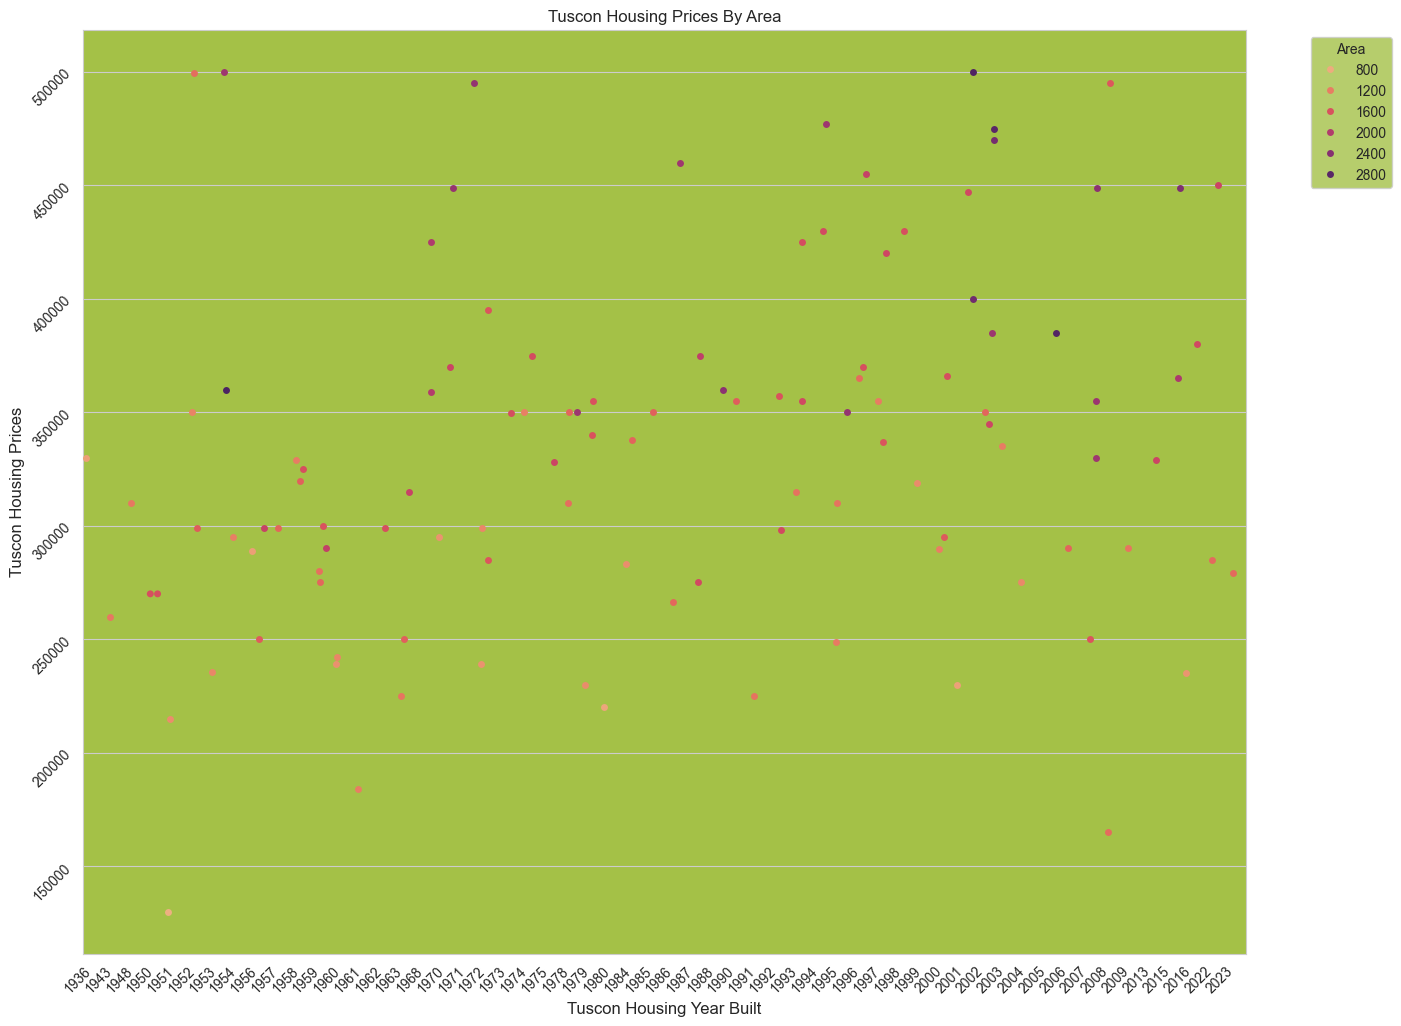

In [140]:
sns.set_style(rc = {'axes.facecolor': "#A4C147"})
plt.Figure(figsize=(15,12))
custom_palette = ["#F3096A", "#6508F0"] # Example hex codes
# Create the swarmplot
fig, ax = plt.subplots(figsize=(15, 12))
sns.swarmplot(data=tucson_housing, y='price', x='year_built', hue='area', palette='flare', dodge=True, legend='auto',size=5)
#sns.lineplot(data=tucson_housing, y='price', x='year_built',ax=saxis)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")
#sns.swarmplot(data=tucson_housing,x='price',y='year_built',hue='area', palette='magma')
plt.title("Tuscon Housing Prices By Area")
#sns.displot(data=tucson_housing,x='year_built',y='type',hue='garage',palette=custom_palette)
plt.xlabel(xlabel='Tuscon Housing Year Built', loc='center',fontsize=12)
plt.ylabel(ylabel='Tuscon Housing Prices', fontsize=12, loc='center')
plt.legend(title='Area', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [146]:
#sns.set_style(rc = {'axes.facecolor': "#A4C147"})
#plt.Figure(figsize=(15,12))
#custom_palette = ["#F3096A", "#6508F0"] # Example hex codes
# Create the swarmplot
#fig, ax = plt.subplots(figsize=(15, 12))
#sns.swarmplot(data=tucson_housing, y='price', x='area', hue='year_built', palette='flare', dodge=True, legend='auto',size=5)
#sns.lineplot(data=tucson_housing, y='price', x='year_built',ax=saxis)
#plt.yticks(rotation=45, ha="right")
#plt.xticks(rotation=45, ha="right")
#sns.swarmplot(data=tucson_housing,x='price',y='year_built',hue='area', palette='magma')
#plt.title("Tuscon Housing Prices By Area and Year Built")
#sns.displot(data=tucson_housing,x='year_built',y='type',hue='garage',palette=custom_palette)
#plt.xlabel(xlabel='Tuscon Housing by Area', loc='center',fontsize=12)
#plt.ylabel(ylabel='Tuscon Housing Prices', fontsize=12, loc='center')
#plt.legend(title='Year Built', bbox_to_anchor=(1.05, 1), loc='upper left')


#plt.show()

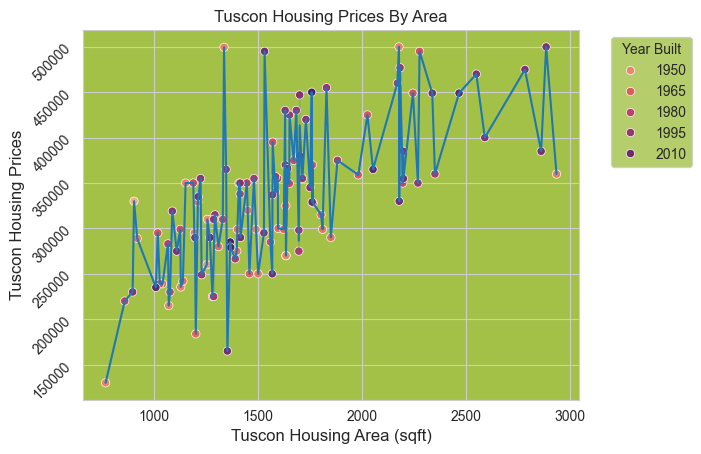

In [141]:
sns.set_style(rc = {'axes.facecolor': "#A4C147"})
plt.Figure(figsize=(15,12))
custom_palette = ["#F3096A", "#6508F0"] # Example hex codes
# Create the swarmplot
#fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=tucson_housing, y='price', x='area', hue='year_built', palette='flare',legend ='auto')
sns.lineplot(data=tucson_housing, y='price', x='area')
plt.yticks(rotation=45, ha="right")



#sns.swarmplot(data=tucson_housing,x='price',y='year_built',hue='area', palette='magma')
plt.title("Tuscon Housing Prices By Area")
#sns.displot(data=tucson_housing,x='year_built',y='type',hue='garage',palette=custom_palette)
plt.xlabel(xlabel='Tuscon Housing Area (sqft)', loc='center',fontsize=12)
plt.ylabel(ylabel='Tuscon Housing Prices', fontsize=12, loc='center')
plt.legend(title='Year Built', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


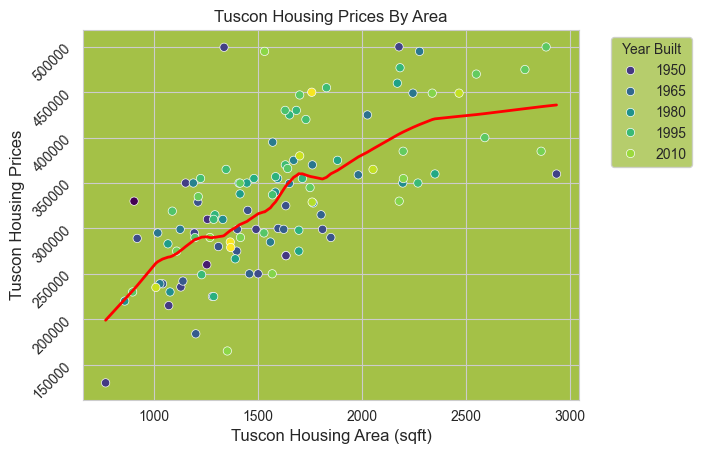

In [145]:
sns.set_style(rc = {'axes.facecolor': "#A4C147"})
plt.Figure(figsize=(15,12))
custom_palette = ["#F3096A", "#6508F0"] # Example hex codes
# Create the swarmplot
#fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=tucson_housing, y='price', x='area', hue='year_built', palette='viridis',legend ='auto')
#sns.lineplot(data=tucson_housing, y='price', x='area')
plt.yticks(rotation=45, ha="right")

lowess_fit = lowess(tucson_housing['price'], tucson_housing['area'], frac=0.3)
lowess_x = [point[0] for point in lowess_fit]
lowess_y = [point[1] for point in lowess_fit]
plt.plot(lowess_x, lowess_y, color='red', linewidth=2)
plt.title('Relationship between House Price and Area in Tucson, Colored by Year Built')

#sns.swarmplot(data=tucson_housing,x='price',y='year_built',hue='area', palette='magma')
plt.title("Tuscon Housing Prices By Area")
#sns.displot(data=tucson_housing,x='year_built',y='type',hue='garage',palette=custom_palette)
plt.xlabel(xlabel='Tuscon Housing Area (sqft)', loc='center',fontsize=12)
plt.ylabel(ylabel='Tuscon Housing Prices', fontsize=12, loc='center')
plt.legend(title='Year Built', bbox_to_anchor=(1.05, 1), loc='upper left')

*Add narrative here.*


According to scatterplot and swornplot chart, I can decide that area can affect the housing prices. Also, newer houses with more square feets are expensive than older one. Bigger and expensive houses are newer ones than smaller and cheaper ones.


::: callout-important
Now is a good time to render, commit, and push.
Make sure that you commit and push all changed documents and your Git pane is completely empty before proceeding.
:::